In [3]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# 1. Khởi tạo Spark kèm theo PostgreSQL JDBC Driver
spark = SparkSession.builder \
    .appName("Postgres_Integration") \
    .config("spark.jars.packages", "org.postgresql:postgresql:42.5.4") \
    .getOrCreate()

print("Đang đọc dữ liệu từ PostgreSQL qua JDBC...")

# 2. Đọc bảng 'sales'
df_sales = spark.read \
    .format("jdbc") \
    .option("url", "jdbc:postgresql://postgres:5432/retail_db") \
    .option("dbtable", "sales") \
    .option("user", "admin") \
    .option("password", "password123") \
    .option("driver", "org.postgresql.Driver") \
    .load()

# --- LÀM SẠCH DỮ LIỆU ---
# 3. Bỏ dòng null ở các cột quan trọng
df_clean = df_sales.dropna(subset=["store_id", "product_id", "quantity", "price"])

# 4. Bỏ dòng có quantity <= 0 hoặc price <= 0
df_clean = df_clean.filter((F.col("quantity") > 0) & (F.col("price") > 0))

# 5. Tạo cột revenue
df_clean = df_clean.withColumn("revenue", F.round(F.col("quantity") * F.col("price"), 2))

# --- TÍNH TOÁN (AGGREGATION) ---
print("\n--- KẾT QUẢ PHÂN TÍCH ---")

# A. Tổng doanh thu
total_revenue = df_clean.select(F.sum("revenue")).collect()[0][0]
print(f"Tổng doanh thu toàn hệ thống: {total_revenue:,.2f} USD")

# B. Doanh thu theo Category
print("\nDoanh thu theo danh mục:")
df_clean.groupBy("category") \
    .agg(F.round(F.sum("revenue"), 2).alias("total_revenue")) \
    .orderBy(F.desc("total_revenue")) \
    .show()

# C. Chuẩn bị dữ liệu Doanh thu theo Store để vẽ biểu đồ
print("Đang gom nhóm theo cửa hàng và chuyển sang Pandas...")
store_revenue_pd = df_clean.groupBy("store_id") \
    .agg(F.round(F.sum("revenue"), 2).alias("store_revenue")) \
    .orderBy(F.desc("store_revenue")) \
    .toPandas()

# Xử lý kiểu dữ liệu của store_id để vẽ biểu đồ đẹp hơn
store_revenue_pd['store_id'] = store_revenue_pd['store_id'].astype(int).astype(str)

Đang đọc dữ liệu từ PostgreSQL qua JDBC...

--- KẾT QUẢ PHÂN TÍCH ---
Tổng doanh thu toàn hệ thống: 28,469,617.20 USD

Doanh thu theo danh mục:
+-------------+-------------+
|     category|total_revenue|
+-------------+-------------+
|      Fashion|1.737759018E7|
|  Electronics|   6415014.75|
|      Grocery|   2386850.17|
|       Beauty|   1204628.19|
|Home & Garden|   1085533.91|
+-------------+-------------+

Đang gom nhóm theo cửa hàng và chuyển sang Pandas...


/tmp/ipykernel_1104/2113594348.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=store_revenue_pd, x='store_id', y='store_revenue', palette='Blues_r')


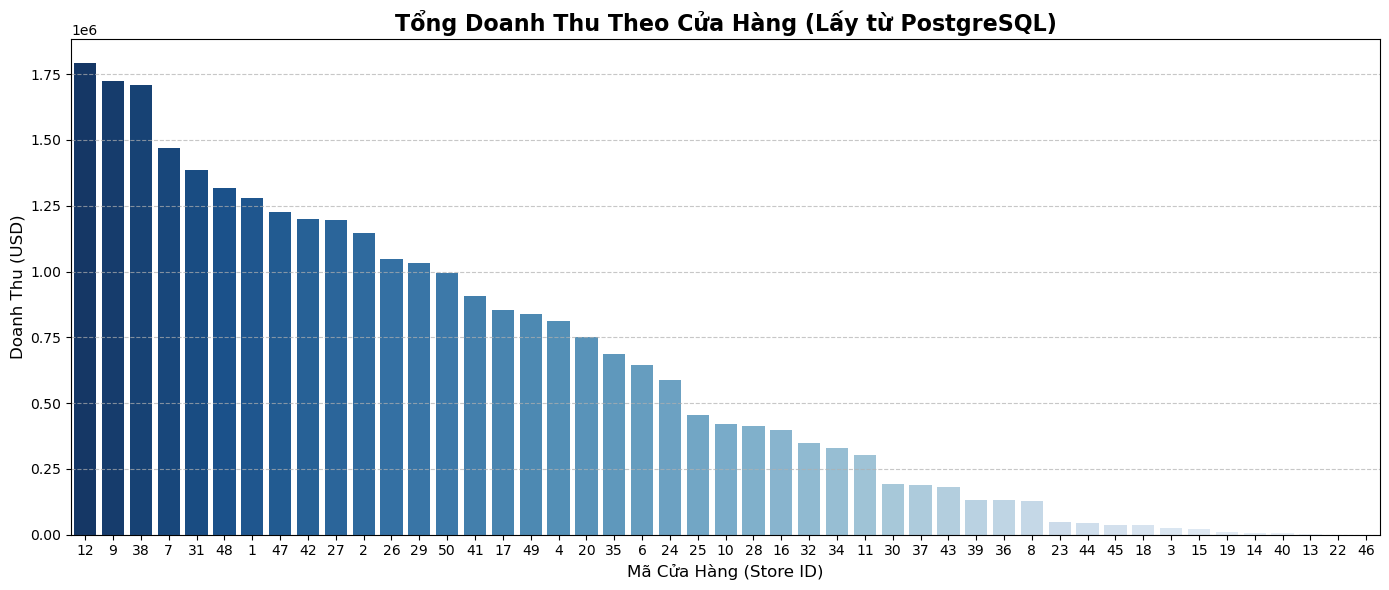

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Vẽ Bar Chart sử dụng Seaborn
sns.barplot(data=store_revenue_pd, x='store_id', y='store_revenue', palette='Blues_r')

# Định dạng biểu đồ
plt.title('Tổng Doanh Thu Theo Cửa Hàng (Lấy từ PostgreSQL)', fontsize=16, fontweight='bold')
plt.xlabel('Mã Cửa Hàng (Store ID)', fontsize=12)
plt.ylabel('Doanh Thu (USD)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Hiển thị
plt.tight_layout()
plt.show()